# 07 · SHAP：解釋每一個預測

`feature_importances_` 只告訴你「整體哪些特徵重要」，但說不出**方向**，也無法解釋**單一一筆預測**為什麼是這個結果。**SHAP** 補上這塊——它是目前模型解釋的黃金標準。

## 學習目標

- 知道內建特徵重要性的侷限
- 用 `shap.TreeExplainer` 算出 SHAP values
- 讀 **beeswarm 摘要圖**（全域）與**單筆解釋**（局部）

## 1. 先訓練一個模型

用乳癌資料訓練 XGBoost，等下來解釋它。

In [1]:
import shap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target
)
model = XGBClassifier(n_estimators=200, max_depth=3, eval_metric="logloss", random_state=42)
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print("SHAP values 形狀:", shap_values.shape, "(每筆樣本、每個特徵都有一個貢獻值)")

SHAP values 形狀: (114, 30) (每筆樣本、每個特徵都有一個貢獻值)


## 2. 全域：beeswarm 摘要圖

每個點是「一筆樣本的一個特徵」。橫軸是 SHAP 值（把預測往哪推、推多少），顏色是特徵值高低。一眼看出**哪些特徵重要、高值是把預測往哪推**。

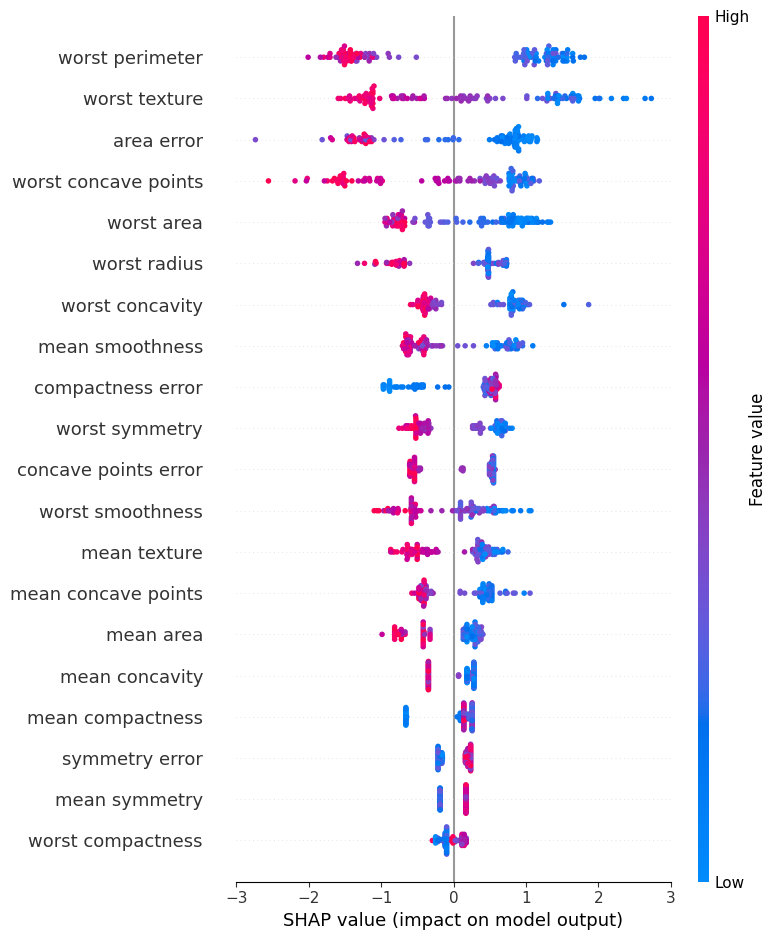

In [2]:
shap.summary_plot(shap_values, X_test, feature_names=data.feature_names, show=True)

比起長條圖，beeswarm 多了**方向**資訊：例如某特徵「值越大（紅）越把預測推向惡性」這種洞察，內建 importance 給不了。

## 3. 局部：解釋單一一筆預測

SHAP 能把**一筆**預測拆解成「從基準值出發，每個特徵各推了多少」。這在要對單一個案交代理由時（為什麼這位病人被判為高風險）極有價值。

In [3]:
import numpy as np

i = 0  # 解釋測試集第一筆
contrib = shap_values[i]
order = np.argsort(np.abs(contrib))[::-1][:6]
print(f"第 {i} 筆預測機率: {model.predict_proba(X_test[i:i+1])[0, 1]:.3f}")
print("貢獻最大的 6 個特徵（正值推向良性、負值推向惡性）:")
for j in order:
    print(f"  {data.feature_names[j]:<28} SHAP={contrib[j]:+.3f}  (值={X_test[i, j]:.1f})")

第 0 筆預測機率: 0.000
貢獻最大的 6 個特徵（正值推向良性、負值推向惡性）:
  worst concave points         SHAP=-1.530  (值=0.2)
  worst perimeter              SHAP=-1.292  (值=178.6)
  worst texture                SHAP=-1.142  (值=36.3)
  area error                   SHAP=-1.133  (值=106.4)
  mean area                    SHAP=-0.815  (值=1207.0)
  worst radius                 SHAP=-0.790  (值=25.1)


## 小結

- 內建 importance 只有全域、沒方向、不能解釋單筆。
- **SHAP** 給每筆樣本、每個特徵一個貢獻值，可加總回預測。
- **beeswarm** 看全域與方向；**單筆 SHAP** 解釋個別預測。

## 練習

1. 換成 `LGBMClassifier`，SHAP 摘要圖的重要特徵排序一樣嗎？
2. 挑一筆模型預測錯的樣本，用單筆 SHAP 看它被哪些特徵帶偏。

最後一課，把整個模組串成一個 **Kaggle 風格的完整專案**。